# 01 · Optimize the flux and plot it

`optimize(data)` minimizes χ². It returns a result with `.x` (the flux
vector), `.fun` (χ², in scaled units — divide by `a.c` for χ²/c), and
`.success`. It also stores the result on `a.result`, which the plotting
and band routines reuse.

In [1]:
import warnings; warnings.simplefilter('ignore')
from neutrino_analysis_band import NeutrinoAnalysis
import numpy as np

a = NeutrinoAnalysis(background_scenario='flat', intervals='180',
                     GeV=0.32e16, solver='scipy', T=3)
res = a.optimize(a.data_vector)
print('success :', res.success)
print('chi2/c  :', res.fun / a.c)

success : True
chi2/c  : 1.1003738244649522e-29


In [2]:
# Flux is monotonically non-increasing (an ordering constraint).
x = res.x
print('first 6 flux values :', np.round(x[:6], 3))
print('monotone non-incr   :', bool(np.all(np.diff(x) <= 1e-6 * np.abs(x).max())))

# Convert to physical units (cm^-2 s^-1):
phys = x * (a.cm**2 * a.sec)
print('flux[0] physical    : %.3e' % phys[0])

first 6 flux values : [8948693.595 8948693.595 8948693.595 8948693.595 8948693.595 8948693.595]
monotone non-incr   : True
flux[0] physical    : 1.059e+12


Plot saved as T3/scenario_bkg_flat/flux_comparison_bkg_flat.pdf


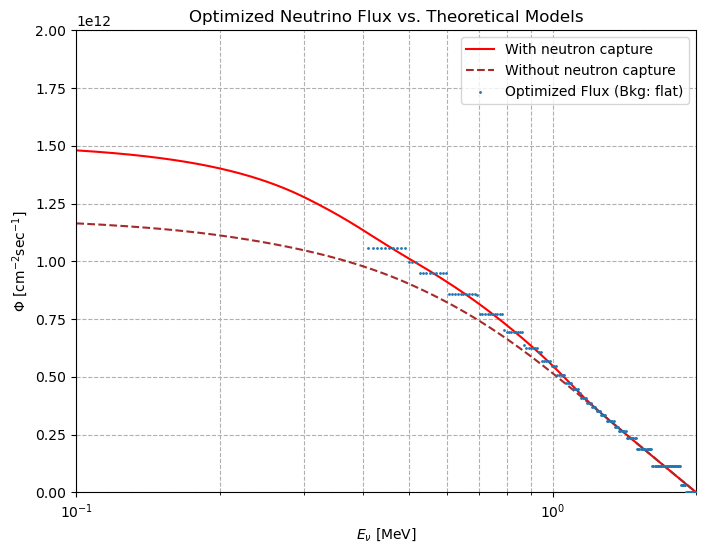

In [3]:
# Plot optimized flux against the theoretical curves.
# save=True writes T3/scenario_bkg_flat/flux_comparison_bkg_flat.pdf
a.plot_flux_comparison(save=True)
import matplotlib.pyplot as plt; plt.show()

**Try it:** change `background_scenario` to `'a'` or `'b'` and re-run.
The optimized χ²/c stays ~0 (the fit is exact) but the flux shape shifts.